In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("All libraries ready!")

All libraries ready!


In [2]:
emp = pd.read_csv('employees.csv')
dept = pd.read_csv('departments.csv')

# Merge
emp_dept = emp.merge(dept, on='dept_id', how='left')

print("Shape:", emp_dept.shape)
emp_dept.head()

Shape: (500, 17)


,emp_id,name,dept_id,designation,experience_years,salary_lakhs,gender,joining_date,performance_rating,certifications,attrition,work_mode,overtime,dept_name,location,head_count,annual_budget_lakhs
0,EMP0001,Employee_1,DEPT07,Senior Manager,1,21.7,Male,2022-03-04,3,4,No,Hybrid,Yes,Cloud Infrastructure,Bangalore,51,63
1,EMP0002,Employee_2,DEPT13,Junior Analyst,12,19.6,Female,2016-04-01,5,0,No,Hybrid,No,Mobile Development,Delhi,71,389
2,EMP0003,Employee_3,DEPT11,Team Lead,10,4.2,Male,2015-04-13,3,2,No,Hybrid,No,Systems Integration,Chennai,71,102
3,EMP0004,Employee_4,DEPT09,Analyst,12,22.1,Female,2018-01-31,3,0,No,Hybrid,No,Technical Support,Bangalore,24,314
4,EMP0005,Employee_5,DEPT03,Team Lead,7,11.1,Female,2017-09-30,2,3,No,Remote,No,Quality Assurance,Bangalore,67,323


In [3]:
# Select features for prediction
features = [
    'experience_years', 'salary_lakhs', 'performance_rating',
    'certifications', 'gender', 'designation', 'work_mode',
    'overtime', 'dept_name'
]

# Target variable
target = 'attrition'

# Create model dataframe
model_df = emp_dept[features + [target]].copy()

# Encode categorical columns
le = LabelEncoder()
cat_cols = ['gender', 'designation', 'work_mode', 'overtime', 'dept_name']

for col in cat_cols:
    model_df[col] = le.fit_transform(model_df[col])

# Encode target
model_df[target] = le.fit_transform(model_df[target])

print("Features ready!")
print(model_df.head())

Features ready!
   experience_years  salary_lakhs  performance_rating  certifications  gender  \
0                 1          21.7                   3               4       1   
1                12          19.6                   5               0       0   
2                10           4.2                   3               2       1   
3                12          22.1                   3               0       0   
4                 7          11.1                   2               3       0   

   designation  work_mode  overtime  dept_name  attrition  
0            4          0         1          1          0  
1            1          0         0         13          0  
2            5          0         0         18          0  
3            0          0         0         19          0  
4            5          2         0         16          0  


In [4]:
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Training samples : 400
Testing samples  : 100


In [5]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("=== LOGISTIC REGRESSION ===")
print(f"Accuracy: {accuracy_score(y_test, lr_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

=== LOGISTIC REGRESSION ===
Accuracy: 80.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        80
           1       0.00      0.00      0.00        20

    accuracy                           0.80       100
   macro avg       0.40      0.50      0.44       100
weighted avg       0.64      0.80      0.71       100



In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("=== RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, rf_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

=== RANDOM FOREST ===
Accuracy: 79.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.88        80
           1       0.00      0.00      0.00        20

    accuracy                           0.79       100
   macro avg       0.40      0.49      0.44       100
weighted avg       0.64      0.79      0.71       100



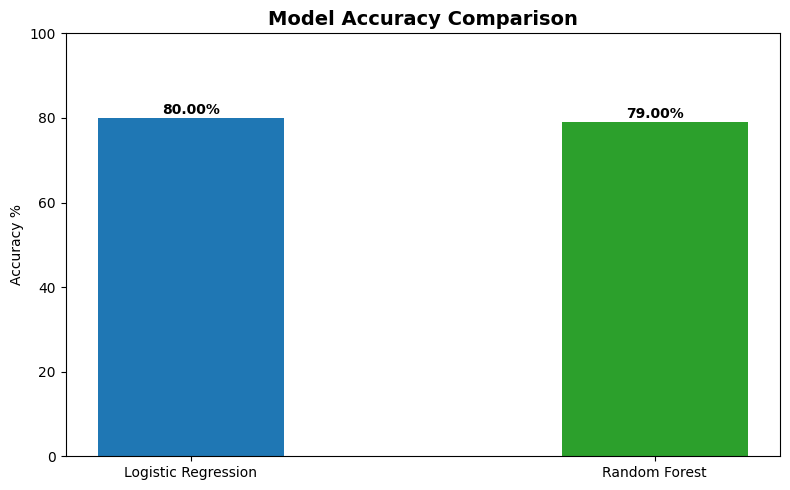

Chart saved!


In [7]:
models = ['Logistic Regression', 'Random Forest']
accuracies = [
    accuracy_score(y_test, lr_pred)*100,
    accuracy_score(y_test, rf_pred)*100
]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['#1F77B4', '#2CA02C'], width=0.4)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy %')
plt.ylim(0, 100)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Chart saved!")

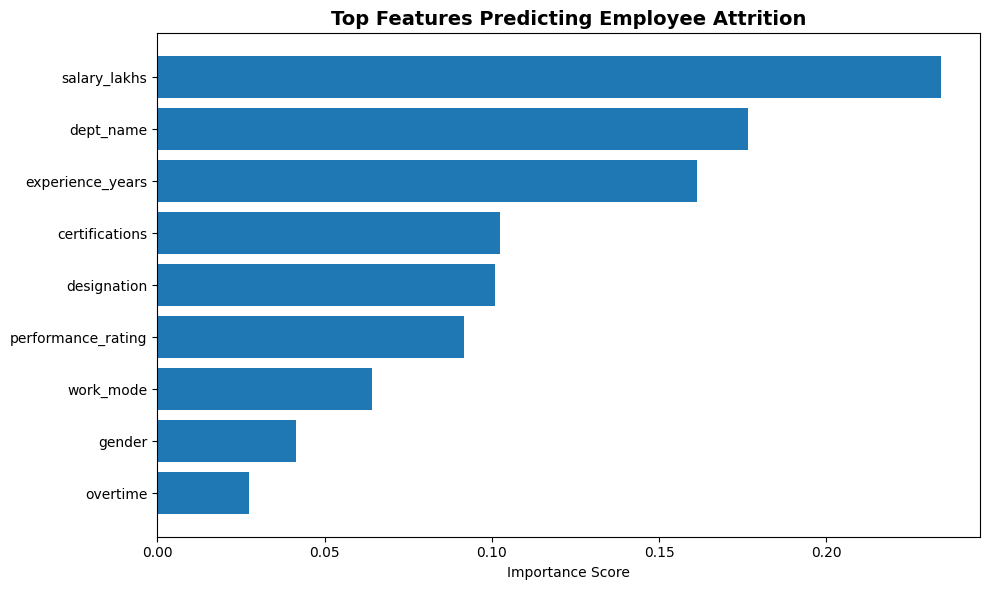

Feature importance chart saved!


In [8]:
# Get feature importance from Random Forest
importance_df = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='#1F77B4')
plt.title('Top Features Predicting Employee Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Feature importance chart saved!")

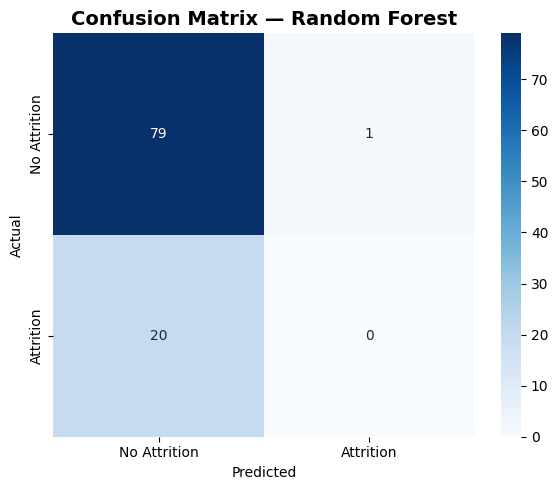

In [9]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
plt.title('Confusion Matrix — Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [10]:
print("=" * 50)
print("       ATTRITION PREDICTION MODEL SUMMARY")
print("=" * 50)
print(f"Total Employees         : {len(emp)}")
print(f"Attrition Rate          : {(emp['attrition']=='Yes').mean()*100:.1f}%")
print(f"Logistic Regression Acc : {accuracy_score(y_test, lr_pred)*100:.2f}%")
print(f"Random Forest Acc       : {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"Best Model              : Random Forest")
top_feature = importance_df.iloc[-1]['feature']
print(f"Top Attrition Factor    : {top_feature}")
print("=" * 50)

       ATTRITION PREDICTION MODEL SUMMARY
Total Employees         : 500
Attrition Rate          : 18.8%
Logistic Regression Acc : 80.00%
Random Forest Acc       : 79.00%
Best Model              : Random Forest
Top Attrition Factor    : salary_lakhs
